# Planar data classification with one hidden layer.

Here we build the NN which has only one hidden layer. We can see a big difference between this model and the one we implemented using  the logistic regression.

Here we:
* Implement a 2-class classification NN with a single hidden layer.
* Use units with a non-linear activation function.
* Compute the cross entropy loss
* Implement the forward and  backward propagation.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from testCases import *
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline
np.random.seed(1)


## Dataset
Let's get the dataset that we'll work on. The following code will load "flower" 2 class dataset into variables `X` and `Y`.

In [2]:
X, Y = load_planar_dataset()

we visualize the dataset using the matplotlib. The data looks like a "flower" which som red(label y=0) and some blue (y=1) points. Our goal is to build a model to fit the data.


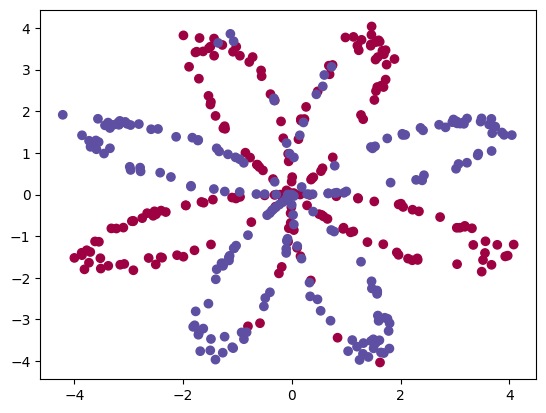

In [3]:
plt.scatter(X[0, :], X[1, :], c =Y, cmap=plt.cm.Spectral);


We've a numpy array (matrix) that contain the features (x1, x2) - a numpy array (vector) Y that contains the labels (red:0, blue 1),

Let first get a better sense of what our data is like.

How many egs, do we have? In addition what is the shape of the variables `X` and `Y`?

In [4]:
shape_X = X.shape
shape_Y = Y.shape
m = Y.shape[1]

print("Shape of X is: ", str(shape_X))
print("Shape of Y is : " + str(shape_Y))
print("I have  m = %d training examples! " % (m))

Shape of X is:  (2, 400)
Shape of Y is : (1, 400)
I have  m = 400 training examples! 


## Simple logistic regression
Before building a full neural network, lets first see how logistic regression performs on this problem. You can use sklearn's built-in functions to do that. Run the code below to train a logistic regression classifier on the dataset.



In [5]:
clf = sklearn.linear_model.LogisticRegressionCV();
clf.fit(X.T, Y.T);

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy of logistic regression: 47 % (percentage of correctly labelled datapoints)


/tmp/ipython-input-1997457913.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ('Accuracy of logistic regression: %d ' % float((np.dot(Y, LR_predictions) + np.dot(1 - Y,1 - LR_predictions)) / float(Y.size) * 100) +


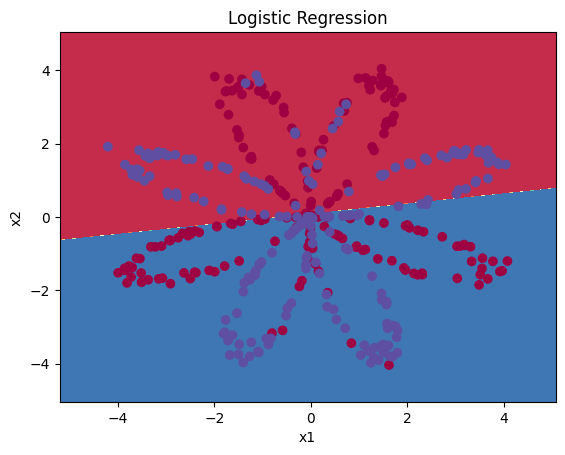

In [6]:
# plottng the decision boundary for the logistic regression.
plot_decision_boundary(lambda x: clf.predict(x), X, Y)
plt.title("Logistic Regression")

LR_predictions = clf.predict(X.T)
print ('Accuracy of logistic regression: %d ' % float((np.dot(Y, LR_predictions) + np.dot(1 - Y,1 - LR_predictions)) / float(Y.size) * 100) +
       '% ' + "(percentage of correctly labelled datapoints)")

**Interpretation** The dataset is not linearly seperable, so logistic regression doesn't perform well. Hopefully n neural network will do better. Let try this now.

## Neural Network Model

Logistic regression did not work well on the "flower dataset". We're going to train a Neural Network with a single hidden layer.

**Here is the model**


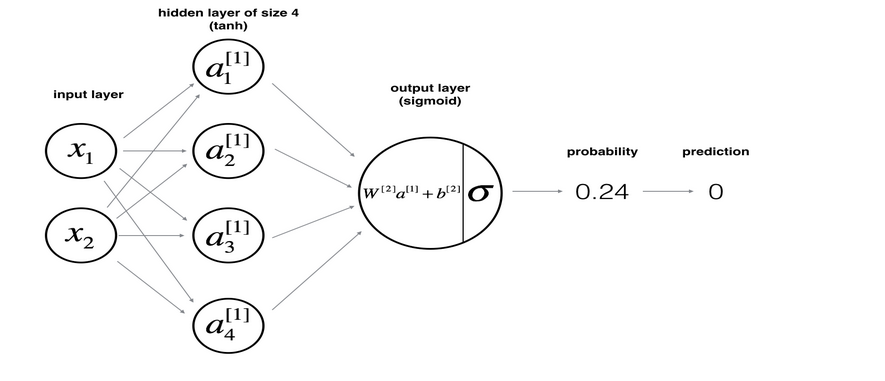



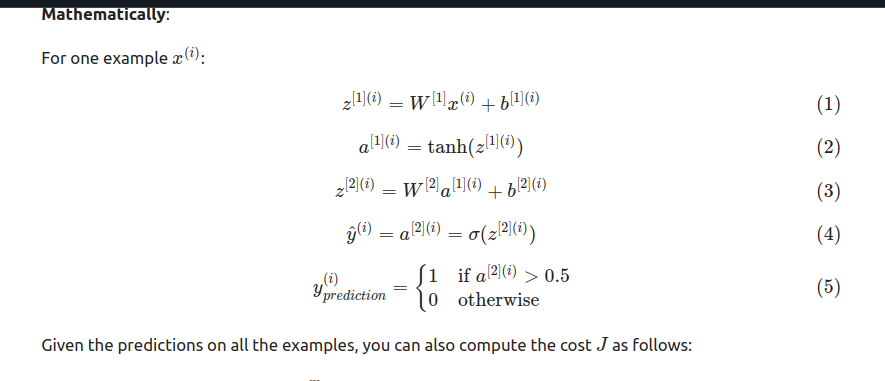
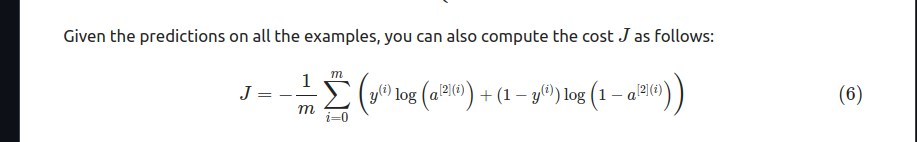


** Remider**:  The general methodology to build a Neural Network is to: 1. Define the neural network structure ( # of input units, # of hidden units, etc). 2. Initialize the model's parameters 3. Loop: - Implement forward propagation - Compute loss - Implement backward propagation to get the gradients - Update parameters (gradient descent).

We often build helper functions to compute steps 1-3 and then merge them into one function we call nn_model(). Once you've built nn_model() and learnt the right parameters, we can make predictions on new data.

### Defining the Neural network structure.
Define three variables: - n_x: the size of the input layer - n_h: the size of the hidden layer (set this to 4) - n_y: the size of the output layer
**Hint** Use shapes of X and Y to find the n_x and n_y . Also hard code the hidden layer size to be 4.


In [7]:
def layer_sizes(X, Y):
  n_x = X.shape[0]
  n_h = 4
  n_y = Y.shape[0]

  return (n_x, n_h, n_y)

In [8]:
X_asses , Y_asses = layer_size_test_case()
(n_x, n_h, n_y) = layer_sizes(X_asses, Y_asses)

print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the hidden layer is: n_h = " + str(n_h))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the hidden layer is: n_h = 4
The size of the output layer is: n_y = 1


## Initialize the model parameters

Implementing the function `initialize_parameters()`.



In [9]:
def initialize_parameters(n_x, n_h, n_y):
  W1 = np.random.randn(n_h, n_x) * 0.01
  b1 = np.random.randn(n_h, 1)
  W2 = np.random.randn(n_y, n_h) * 0.01
  b2 = np.random.randn(n_y, 1)

  assert(W1.shape ==  (n_h, n_x))
  assert(b1.shape == (n_h, 1))
  assert(W2.shape == (n_y, n_h))
  assert(b2.shape == (n_y, 1))

  parameters = {"W1": W1,
               "b1": b1,
               "W2": W2,
               "b2": b2}

  return parameters

In [10]:
n_x, n_h , n_y = initialize_parameters_test_case()

parameters = initialize_parameters(n_x, n_h, n_y)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[-0.00416758 -0.00056267]
 [-0.02136196  0.01640271]
 [-0.01793436 -0.00841747]
 [ 0.00502881 -0.01245288]]
b1 = [[-1.05795222]
 [-0.90900761]
 [ 0.55145404]
 [ 2.29220801]]
W2 = [[ 0.00041539 -0.01117925  0.00539058 -0.0059616 ]]
b2 = [[-0.0191305]]


## The Loop
Implementing the `forward_propagation`

*

In [11]:
def forward_propagation(X, parameters):
  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W2 = parameters["W2"]
  b2 = parameters["b2"]

  Z1 = np.dot(W1, X) + b1
  A1 = np.tanh(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = sigmoid(Z2)

  assert(A2.shape == (1, X.shape[1]))

  cache = {"Z1": Z1,
           "A1": A1,
           "Z2": Z2,
           "A2": A2
           }
  return A2, cache

In [12]:
X_asses , parameters = forward_propagation_test_case()
A2, cache = forward_propagation(X_asses, parameters)


print(np.mean(cache["Z1"]), np.mean(cache["A1"]), np.mean(cache["Z2"]), np.mean(cache["A2"]))

0.01142276543652899 0.011415753585803143 0.00011695903304872518 0.5000292397574749


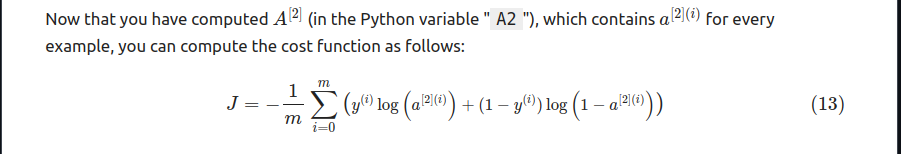

Now we implement `compute_cost()` to compute the value of the cost J.


In [13]:
def compute_cost(A2, Y, parameters):
  m = Y.shape[1]

  W1 = parameters["W1"]
  W2 = parameters["W2"]

  logprobs = np.multiply(np.log(A2), Y) + np.multiply((1 - Y), np.log(1 - A2))

  cost = -np.sum(logprobs) / m

  cost = np.squeeze(cost)

  assert(isinstance(cost, float))

  return cost


In [14]:
A2, Y_asses , parameters = compute_cost_test_case()

print("cost = " + str(compute_cost(A2, Y_asses, parameters)))

cost = 0.6927392543483354


Using the cache computed during forward propagation, you can now implement backward propagation.

Implemeting the **backward propagation**
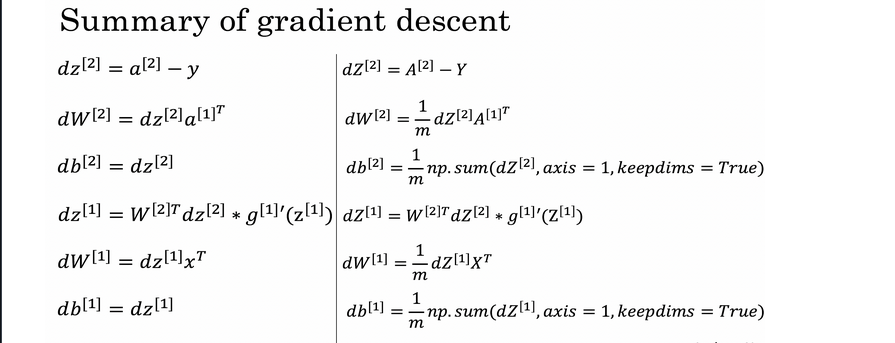


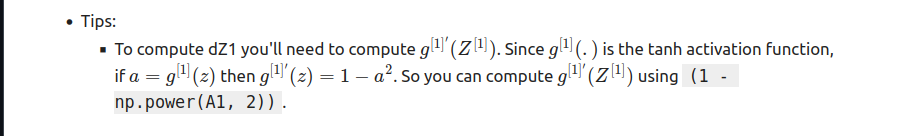

In [15]:
def backward_propagation(parameters, cache, X, Y):
  m = X.shape[1]

  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W2 = parameters["W2"]
  b2 = parameters["b2"]

  A1 = cache['A1']
  A2 = cache['A2']

  dZ2 = A2 - Y
  dW2 = (1 / m ) * np.dot(dZ2, A1.T)
  db2 = (1 / m) * np.sum(dZ2,  axis=1, keepdims=True)
  dZ1 = np.multiply(np.dot(W2.T, dZ2), 1 - np.power(A1, 2))
  dW1 = (1 / m) * np.dot(dZ1, X.T)
  db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

  grads = {"dW1": dW1,
           "db1": db1,
           "dW2": dW2,
           "db2": db2}

  return grads



In [16]:
parameters, cache, X_assess, Y_assess = backward_propagation_test_case()

grads = backward_propagation(parameters, cache, X_asses, Y_asses)
print ("dW1 = "+ str(grads["dW1"]))
print ("db1 = "+ str(grads["db1"]))
print ("dW2 = "+ str(grads["dW2"]))
print ("db2 = "+ str(grads["db2"]))

dW1 = [[-0.00090672  0.00225347]
 [ 0.00070977 -0.00176209]
 [-0.00414843  0.01032228]
 [ 0.00585261 -0.01454977]]
db1 = [[-0.00053089]
 [ 0.00041556]
 [-0.00242857]
 [ 0.00342669]]
dW2 = [[-0.00589694 -0.00219552 -0.00952323 -0.00666972]]
db2 = [[-0.16666332]]


**Implementing the update rule**. $\[
\theta = \theta - \alpha \frac{\partial J}{\partial \theta}
\]$




In [17]:
def update_parameters(parameters, grads, learning_rate=1.2):
  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W2 = parameters["W2"]
  b2 = parameters["b2"]

  dW1 = grads["dW1"]
  db1 = grads["db1"]
  dW2 = grads["dW2"]
  db2 = grads["db2"]

  W1 = W1 - learning_rate * dW1
  b1 = b1 - learning_rate * db1
  W2 = W2 - learning_rate * dW2
  b2 = b2 - learning_rate * db2

  parameters = {
      "W1": W1,
      "b1": b1,
      "W2": W2,
      "b2": b2
  }

  return parameters

In [18]:
parameters, grads = update_parameters_test_case()
parameters = update_parameters(parameters, grads)


print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))


W1 = [[-0.01639208  0.00794174]
 [-0.03184332  0.02369487]
 [-0.0115642  -0.01285002]
 [ 0.03150519 -0.03087439]]
b1 = [[-0.00245656]
 [-0.00209704]
 [ 0.00127403]
 [ 0.00529528]]
W2 = [[-0.01494288 -0.04693333 -0.00844043  0.03874187]]
b2 = [[-0.07907387]]


## Integarting the parts: 4.1, 4.2 and 4.3 in nn_model().
: Building  our neural network model in `nn_model()`.

 The NN model has to use the prev: functions in the right order.

In [19]:
def nn_model(X, Y, n_h,  num_iterations=10000, print_cost=False):
  np.random.seed(3)
  n_x = layer_sizes(X, Y)[0]
  n_y = layer_sizes(X, Y)[2]


  parameters = initialize_parameters(n_x, n_h, n_y)
  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W1 = parameters["W2"]
  b2 = parameters["b2"]

  for i in range(0, num_iterations):
    A2, cache = forward_propagation(X, parameters)

    cost = compute_cost(A2, Y, parameters)

    grads = backward_propagation(parameters, cache, X, Y)

    parameters = update_parameters(parameters, grads)

    if print_cost and i % 1000 == 0:
      print("Cost after evry iteration %i: %f" % (i, cost))

  return parameters


In [20]:
X_assess, Y_assess = nn_model_test_case()

parameters = nn_model(X_assess, Y_assess, 4, num_iterations=10000, print_cost=False)
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["W2"]))
print("b2 = " + str(parameters["b2"]))



W1 = [[-2.18109773 -2.64482339]
 [ 4.24531743  4.87575925]
 [ 0.25066361  0.40464463]
 [-2.73962759 -3.22070366]]
b1 = [[-0.27509728]
 [ 0.41835647]
 [-1.01656931]
 [-0.30002475]]
W2 = [[ 3.64350036 -7.52412814 -0.60303165  4.56547991]]
b2 = [[-0.27660863]]


### Predictions

using our model to predict by building predict(). using the forward propagation results.

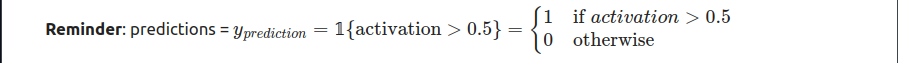
As an example, if you would like to set the entries of a matrix X to 0 and 1 based on a threshold you would do: `X_new = (X > threshold)`

In [21]:
def predict(parameters, X):
  A2, cache = forward_propagation(X, parameters)

  predictions = np.round(A2)

  return predictions



In [22]:
parameters, X_asses = predict_test_case()

predictions = predict(parameters, X_asses)
print("Prediction mean = " + str(np.mean(predictions)))

Prediction mean = 0.8


Let runthe model and see how it perfroms on a planar dataset.

Cost after evry iteration 0: 0.731345
Cost after evry iteration 1000: 0.281365
Cost after evry iteration 2000: 0.265490
Cost after evry iteration 3000: 0.257196
Cost after evry iteration 4000: 0.252001
Cost after evry iteration 5000: 0.248484
Cost after evry iteration 6000: 0.245976
Cost after evry iteration 7000: 0.244111
Cost after evry iteration 8000: 0.242677
Cost after evry iteration 9000: 0.241543


Text(0.5, 1.0, 'Decision Boundary for hidden layer size: 4')

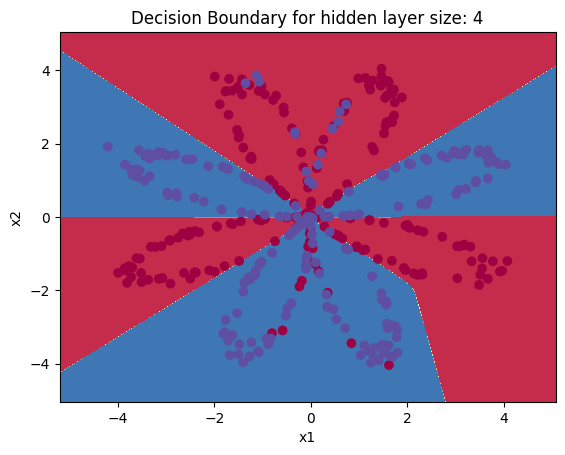

In [24]:
parameters = nn_model(X, Y, n_h = 4, num_iterations=10000, print_cost=True)

plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
plt.title("Decision Boundary for hidden layer size: " + str(4))

In [25]:
# plotting accuracy
predictions = predict(parameters, X)
print("Accuracy: %d" % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')

Accuracy: 90%


/tmp/ipython-input-3155504778.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Accuracy: %d" % float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100) + '%')


Accuracy is really high compared to Logistic Regression. The model has learnt the leaf patterns of the flower! Neural networks are able to learn even highly non-linear decision boundaries, unlike logistic regression.

Now we try several hidden layer sizes


### Tuning hidden layer size



/tmp/ipython-input-709893317.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)


Accuray for 1 hidden units: 67.5 %
Accuray for 2 hidden units: 67.25 %
Accuray for 3 hidden units: 90.75 %
Accuray for 4 hidden units: 90.5 %
Accuray for 5 hidden units: 90.25 %
Accuray for 20 hidden units: 91.25 %
Accuray for 50 hidden units: 90.75 %


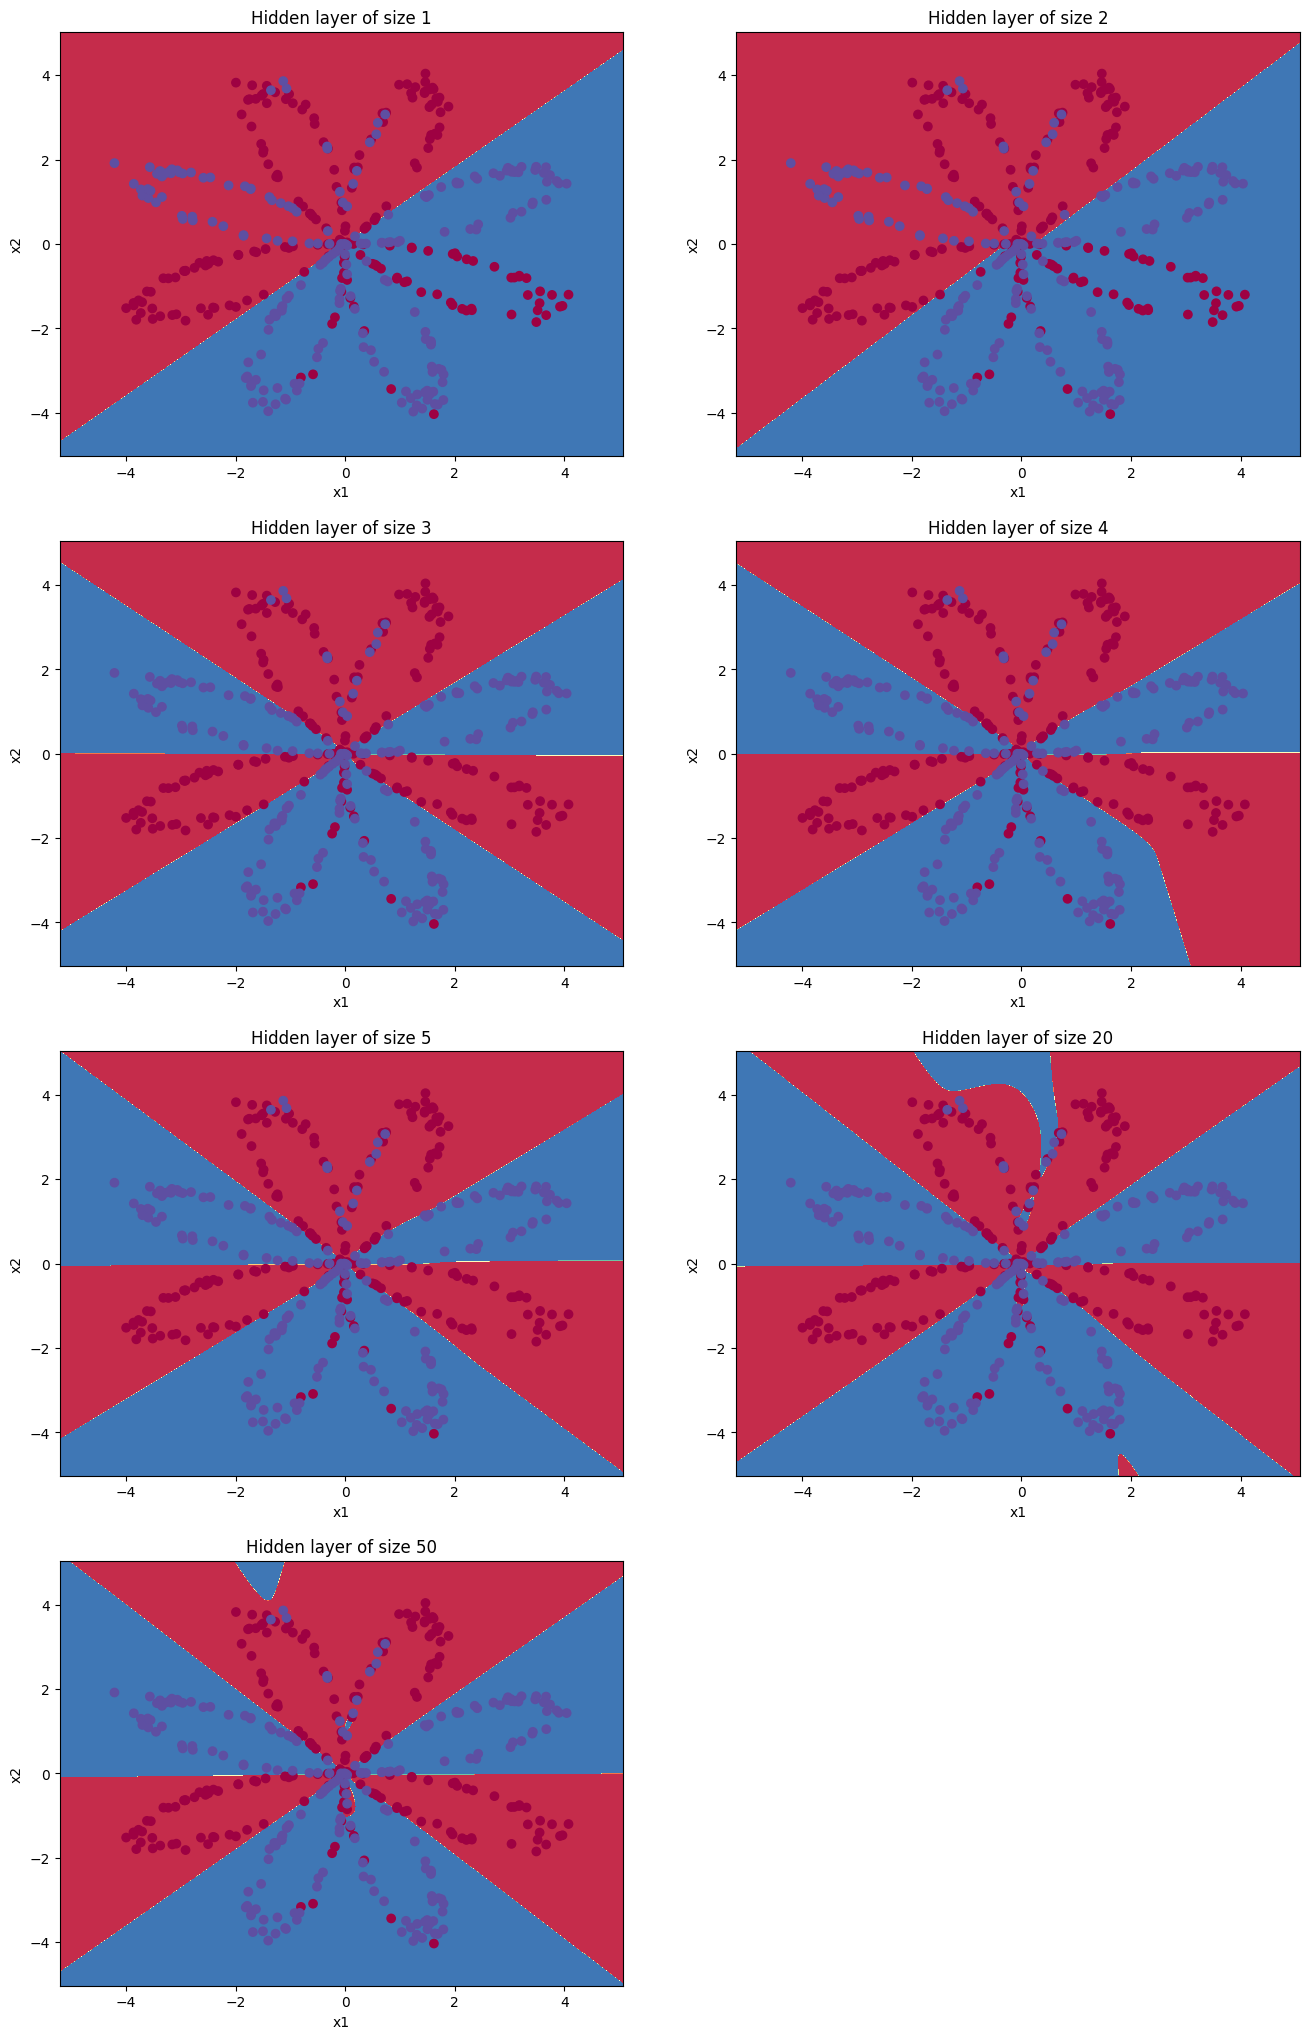

In [27]:
plt.figure(figsize=(16, 32))
hidden_layer_sizes = [1, 2, 3, 4, 5, 20, 50]

for i , n_h in enumerate(hidden_layer_sizes):
  plt.subplot(5, 2, i + 1)
  plt.title("Hidden layer of size %d" % n_h)
  parameters = nn_model(X, Y, n_h, num_iterations=5000)
  plot_decision_boundary(lambda x: predict(parameters, x.T), X, Y)
  predictions = predict(parameters, X)
  accuracy = float((np.dot(Y, predictions.T) + np.dot(1 - Y, 1 - predictions.T)) / float(Y.size) * 100)
  print("Accuray for {} hidden units: {} %".format(n_h, accuracy))



**Interpretation**


* The larger models (with more hidden units) are able to fit the training set better, until eventually the largest models overfit the data.
* The best hidden layer size seems to be around n_h = 5. Indeed, a value around here seems to fits the data well without also incurring noticable overfitting.
* With regularization we can use the large models (such as n_h = 50) without much overfitting.

## Performance on other datasets


If we want, we can rerun the whole notebook (minus the dataset part) for each of the following datasets.
(we can chose to do it later?)

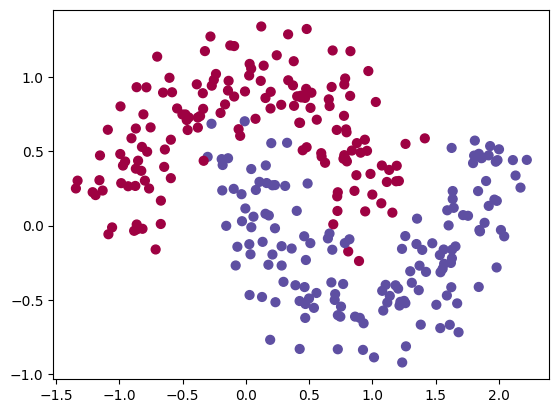

In [29]:
noisy_circles, noisy_moons, blobs, gaussian_quantiles, no_structure = load_extra_datasets()

datasets = {"noisy_circles": noisy_circles,
            "noisy_moons": noisy_moons,
            "blobs": blobs,
            "gaussian_quantiles": gaussian_quantiles}

### START CODE HERE ### (choose your dataset)
dataset = "noisy_moons"
### END CODE HERE ###

X, Y = datasets[dataset]
X, Y = X.T, Y.reshape(1, Y.shape[0])

# make blobs binary
if dataset == "blobs":
    Y = Y % 2

# Visualize the data
plt.scatter(X[0, :], X[1, :], c=Y, s=40, cmap=plt.cm.Spectral);